In [1]:
## Python in-built tools 
import os
import pickle as pkl
from tqdm import tqdm

## Data Science Tools 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches 
%matplotlib inline
import torch
import torch.nn as nn

## Image Processing Tools 
import cv2
import selectivesearch
from torch.utils.data import Dataset, DataLoader 


## Frameworks
from torchvision import transforms
from torchvision import models
from torchsummary import summary


In [3]:
image_paths=r'D:\Code\Machine_Learning\DeepLearning\DL_Training\phase2\Object detection\implementation\images'
csv_path=r"D:\Code\Machine_Learning\DeepLearning\DL_Training\phase2\Object detection\implementation\df.csv"
batch_size=2
n_epochs=10
learning_rate=0.0001
threshold_iou = 0.3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   

In [35]:
class OpenImageDataset(Dataset):
    def __init__(self, image_paths, csv_path):
        super().__init__()
        self.image_paths = image_paths  
        self.csv_path = csv_path
        self.df = pd.read_csv(csv_path)
        self.unique_images = self.df['ImageID'].unique()


    def __len__(self):
        return len(self.unique_images)
    
    def __getitem__(self, index):
        if isinstance(index, slice):
            indices = range(*index.indices(len(self.unique_images)))
            return [self._load_item(i) for i in indices]
        else:
            return self._load_item(index)
    
    def _load_item(self, index):
        
        image_id = self.unique_images[index]
        image_full_path = os.path.join(self.image_paths, image_id + ".jpg")  
        image = cv2.imread(image_full_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w, _ = image.shape
    

        # Filter dataframe for the corresponding image_id
        df = self.df.loc[self.df['ImageID'] == image_id]
        
        # Get bounding boxes and scale them based on image dimensions
        bboxes = df[['XMin', 'YMin', 'XMax', 'YMax']].values
        bboxes = (bboxes * np.array([w, h, w, h])).astype(np.uint16)
        # print(bboxes)
        # Get the class labels
        classes = df['LabelName'].values
      

        return image, bboxes, classes, image_full_path
    
datasets=OpenImageDataset(image_paths,csv_path)


['Bus' 'Bus' 'Bus' 'Bus' 'Bus']


<function matplotlib.pyplot.show(close=None, block=None)>

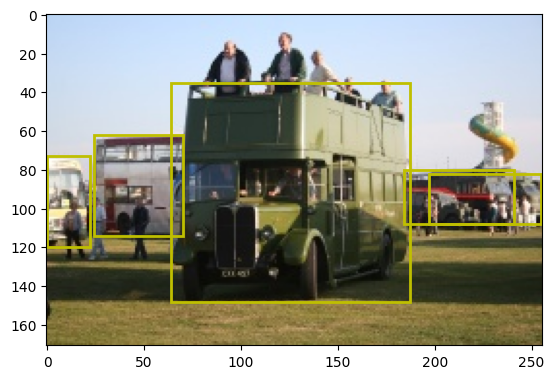

In [34]:
img, bbx, _, _ = datasets[14]
plt.imshow(img)
plt.axis('on')
mt=[]
for bb in bbx:
    # print(bb,bb[:2],bb[2],bb[0],bb[3],bb[1]) #bb[:2]--> xmin,ymin, bb[2]-->xmax, bb[0]-->xmin, bb[3]-->ymax, bb[1]-->ymin
    rect = patches.Rectangle(bb[:2], bb[2]-bb[0], bb[3]-bb[1], edgecolor = 'y', facecolor = 'none', linewidth = 2)
    # print(rect)
    plt.gca().add_patch(rect)
    mt.append(rect)
plt.show



In [6]:
def extract_candidates(img):
    _, regions = selectivesearch.selective_search(img, scale=100, min_size=50)
    # print(regions)
    candidates = []
    img_area = np.prod(img.shape[:2])
    for region in regions:
        if region['rect'] in candidates:
            continue
        if region['size'] < 0.05*img_area:
            continue
        if region['size'] > img_area:
            continue 
        candidates.append(region['rect'])
    return candidates

def extract_iou(bbox1, bbox2, epsilon=1e-5):
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])

    width = x2 - x1
    height = y2 - y1

    if width < 0 or height < 0:
        return 0
    
    intersection_area = width * height 
    area_1 = (bbox1[2] - bbox1[0]) * (bbox1[3] - bbox1[1])
    area_2 = (bbox2[2] - bbox2[0]) * (bbox2[3] - bbox2[1])

    union_area = area_1 + area_2 - intersection_area
    
    return intersection_area / (union_area + epsilon)
# extract_candidates(img)

In [7]:
def save_pickle(var,path):
    with open(path,'wb') as f:
        pkl.dump(var,f) 

def load_pickle(path):
    with open(path,'rb') as f:
        return pkl.load(f)

In [ ]:
# FULL_PATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [], [], [], [], [], []
# # FULL_PATHS=load_pickle('FULL_PATHS.pkl')
# # GTBBS=load_pickle('GTBBS.pkl')
# # CLSS=load_pickle('CLSS.pkl')
# # DELTAS=load_pickle('DELTAS.pkl')
# # ROIS=load_pickle('ROIS.pkl')
# # IOUS=load_pickle('IOUS.pkl')

# # N = 15000
# for i, (image, bboxes, classes, image_full_path) in enumerate(datasets[15000:]):
#     # if i == N:
#     #     break
#     print(f"\rProcessing {i+1}", end="")
#     H, W, _ = image.shape
#     candidates = extract_candidates(image)
#     candidates = np.array([(x, y, x+w, y+h) for x, y, w, h in candidates])

#     clss, deltas, rois = [], [], []
#     ious = np.array([[extract_iou(candidate, bbox) for bbox in bboxes] for candidate in candidates])
    
#     for j, candidate in enumerate (candidates):
#         cx, cy, cX, cY = candidate
#         candidate_ious = ious[j]
#         best_iou_at = np.argmax(candidate_ious)
#         best_iou = candidate_ious[best_iou_at]
#         best_bb = _x, _y, _X, _Y = bboxes[best_iou_at]

#         if best_iou > threshold_iou:
#             clss.append(classes[best_iou_at])
#         else:
#             clss.append('background')

#         delta = np.array([_x-cx, _y-cy, _X-cX, _Y-cY]) / np.array([W, H, W, H])
#         deltas.append(delta)

#         rois.append(candidate / np.array([W, H, W, H]))

#     FULL_PATHS.append(image_full_path)
#     GTBBS.append(bboxes)
#     CLSS.append(clss)
#     DELTAS.append(deltas)
#     ROIS.append(rois)
#     IOUS.append(ious)
    


# Pickle Utils Function

In [ ]:
# def save_pickle(var,path):
#     with open(path,'wb') as f:
#         pkl.dump(var,f) 

# def load_pickle(path):
#     with open(path,'rb') as f:
#         return pkl.load(f)

# save_pickle(FULL_PATHS, 'FULL_PATHS.pkl')
# save_pickle(GTBBS, 'GTBBS.pkl')
# save_pickle(CLSS, 'CLSS.pkl')
# save_pickle(DELTAS, 'DELTAS.pkl')
# save_pickle(ROIS, 'ROIS.pkl')
# save_pickle(IOUS, 'IOUS.pkl')
# F_PATH=load_pickle('FULL_PATHS.pkl')


In [8]:
FULL_PATHS=load_pickle('FULL_PATHS.pkl')
GTBBS=load_pickle('GTBBS.pkl')
CLSS=load_pickle('CLSS.pkl')
DELTAS=load_pickle('DELTAS.pkl')
ROIS=load_pickle('ROIS.pkl')
IOUS=load_pickle('IOUS.pkl')

In [42]:
FULL_PATHS = [
    i.replace(
        r'D:\Code\DeepLearning\phase2\Object detection\implementation\images',
        r'D:\Code\Machine_Learning\DeepLearning\DL_Training\phase2\Object detection\implementation\images'
    )
    for i in FULL_PATHS
]


In [44]:
len(FULL_PATHS), len(GTBBS), len(CLSS), len(DELTAS), len(ROIS), len(IOUS)

(15225, 15225, 15225, 15225, 15225, 15225)

In [45]:
unique_labels = np.unique(np.array([c for clss in CLSS for c in clss])) # 2d data lai 1d ma lerayera unique label nikaleko
target2label = {i:label for i, label in enumerate(unique_labels)}
label2target = {label:i for i, label in enumerate(unique_labels)}

print(target2label)

{0: np.str_('Bus'), 1: np.str_('Truck'), 2: np.str_('background')}


# Dataset for RCNN

In [46]:
def preprocess(crop_img):
    crop_img = torch.tensor(crop_img).permute(2, 0, 1)
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    crop_img = normalize(crop_img)
    return crop_img.float()


class RCNNDataset(Dataset):
    def __init__(self, fpaths, rois, gtbbs, labels, deltas, ious):
        super().__init__()
        self.fpaths = fpaths
        self.rois = rois
        self.gtbbs = gtbbs
        self.labels = labels
        self.deltas = deltas
        self.ious = ious
        self.label2target = {'background': 0, 'bus': 1}

    def __len__(self):
        return len(self.fpaths)

    def __getitem__(self, index):
        fpath = self.fpaths[index]
        
        print(fpath)
        
        image = cv2.imread(fpath, cv2.IMREAD_COLOR)[..., ::-1]  # Convert BGR to RGB
        H, W, _ = image.shape

        gtbbs = self.gtbbs[index]

        rois = self.rois[index]
        bbs = (rois * np.array([W, H, W, H])).astype(np.uint8)
     
        crops = [image[y:Y, x:X] for x, y, X, Y in bbs]
        labels = self.labels[index]
        deltas = self.deltas[index]
        

        return image, gtbbs, bbs, crops, labels, deltas, fpath

    def collate_fn(self, batch):
        inputs, output_labels, output_deltas = [], [], []
        for i in range(len(batch)):
            image, gtbbs, bbs, crops, labels, deltas, fpath = batch[i]
            
            # Resize valid crops and preprocess them
            crops = [cv2.resize(crop,(224, 224)) for crop in crops ]
            crops = [preprocess(crop/255.0)[None] for crop in crops]
            
            inputs.extend(crops)
            output_labels.extend([label2target[label] for label in labels])
            output_deltas.extend(deltas)

        inputs = torch.cat(inputs).to(device)
        output_labels = torch.tensor(output_labels).long().to(device)
        output_deltas = torch.tensor(output_deltas).float().to(device)

        return inputs, output_labels, output_deltas






n_train = int(len(FULL_PATHS) * 0.8)

train_dataset = RCNNDataset(FULL_PATHS[:n_train], ROIS[:n_train], GTBBS[:n_train], CLSS[:n_train], DELTAS[:n_train], IOUS[:n_train])
test_dataset = RCNNDataset(FULL_PATHS[n_train:], ROIS[n_train:], GTBBS[n_train:], CLSS[n_train:], DELTAS[n_train:], IOUS[n_train:])


In [47]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=train_dataset.collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, collate_fn=test_dataset.collate_fn)

# Model Architecture

In [50]:
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
# backbone.avgpool = nn.Sequential()
backbone.fc = nn.Sequential()

for param in backbone.parameters():
    param.requires_grad = False
backbone.to(device=device) 
summary(backbone.to(device), (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [51]:
class RCNN(nn.Module):
    def __init__(self, backbone,n_classes):
        super().__init__()
        self.backbone = backbone
        self.n_classes = n_classes
        
        self.classification_head = nn.Linear(2048,n_classes)

        self.bbox_regression_head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 4),
            nn.Tanh()
        )
        
    def forward(self, inputs):
        feat = self.backbone(inputs)

        cls_score = self.classification_head(feat)
        
        deltas = self.bbox_regression_head(feat)
        
        return cls_score, deltas

            
#inputs, _ , _ = next(iter(train_dataloader))
model = RCNN(backbone=backbone, n_classes=len(unique_labels)).to(device=device)
model = torch.nn.DataParallel(model).to(device)


    

In [52]:
from torch import optim
from torchvision import models
criterion_cls = nn.CrossEntropyLoss()
criterion_bbox = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
n_epochs=5


In [53]:
def train_batch(imgs,kps,model,optimizer,criterion):
    model.train()
    optimizer.zero_grad()
    pred=model(imgs)
    loss=criterion(pred,kps)
    
    loss.backward()
    optimizer.step()
    return loss

In [54]:
@torch.no_grad()
def model_test(img,kps,model,criterion):
    model.eval()
    pred=model(img)
    loss=criterion(pred,kps)

    return loss

In [ ]:
train_loss = []
test_loss=[]

for epoch in range(1, n_epochs + 1):
    
    epoch_loss = 0
    epoch_tloss=0
    
    for inputs, labels, deltas in tqdm(train_dataloader, desc=f'Training Epoch {epoch}/{n_epochs}'):
        model.train()
        cls_preds, bbox_preds = model(inputs)
    
        loss_cls = criterion_cls(cls_preds, labels)
        loss_bbox = criterion_bbox(bbox_preds, deltas)
        loss = loss_cls + loss_bbox
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_tloss += loss.item()
    
    epoch_tloss /= len(train_dataloader)
    train_loss.append(epoch_tloss)
    
    for inputs, labels, deltas in tqdm(test_dataloader, desc=f'Training Epoch {epoch}/{n_epochs}'):
        model.eval()
        cls_preds, bbox_preds = model(inputs)
    
        loss_cls = criterion_cls(cls_preds, labels)
        loss_bbox = criterion_bbox(bbox_preds, deltas)
        loss = loss_cls + loss_bbox
        
        epoch_loss += loss.item()
    
    epoch_loss /= len(test_dataloader)
    train_loss.append(epoch_loss)
    
    print(f'Epoch {epoch}/{n_epochs}: Train Loss: {epoch_tloss:.4f} Test Loss: {epoch_loss:4f}')
torch.save(model.state_dict(),'model.pth')

In [55]:
import torch
from torchvision import models  


model = RCNN(backbone=backbone, n_classes=len(unique_labels))  # recreate model
model = torch.nn.DataParallel(model).to(device)                # wrap again if needed
model.load_state_dict(torch.load('model.pth', map_location=device))
model.eval()  # set to evaluation mode if using for inference



DataParallel(
  (module): RCNN(
    (backbone): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplac

In [85]:
test_img =  cv2.imread(r'D:\Code\Machine_Learning\DeepLearning\DL_Training\phase2\Object detection\implementation\images\0a0b34cd17d2a797.jpg',
                       cv2.IMREAD_COLOR)[..., ::-1]  # Convert BGR to RGB

                     

In [86]:
test_img = preprocess(test_img/255.0)[None].to(device)

In [87]:
cls_score, deltas = model(test_img)
cls_score,deltas  


(tensor([[ 0.3925, -0.2933, -1.6284]], grad_fn=<AddmmBackward0>),
 tensor([[ 0.0718,  0.0954, -0.0637, -0.0686]], grad_fn=<TanhBackward0>))

In [88]:
pred_class = torch.argmax(cls_score, dim=1).item()
pred_class = unique_labels[pred_class]
pred_class


np.str_('Bus')